# CSE 445 — Computer Vision
## Part B — Notebook 4b: DINOv3 -> YOLOv26 Detection at 20% Labels

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA — High-Resolution Drone Imagery for Military Object Detection and Recognition. |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Model** | DINOv3 DETECT |

---

**What this notebook does**
- Head warm-up (10 epochs, backbone frozen) + full fine-tune (140 epochs) = 150 epochs total — the
   same two-stage protocol used for SimCLR/BYOL, kept identical here for fairness across all four SSL
   methods, rather than switching to a different single-stage recipe.
- Also fine-tunes the two **baselines** (random-init, COCO-pretrained) at the same 20% budget,
   independently in this notebook (self-contained, no dependency on any other SSL notebook's output).


## 1. Install `ssldet` and imports

In [1]:
%pip install -q --upgrade "git+https://github.com/rifat963/ssl-detection-lab.git@main"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 2.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from packaging.version import Version
from ultralytics import YOLO

import ssldet
from ssldet import EvaluationConfig, evaluate

sns.set_theme(style="whitegrid", context="notebook")
REQUIRED_SSLDET_VERSION = "0.8.1"
assert Version(ssldet.__version__) >= Version(REQUIRED_SSLDET_VERSION), (
    f"ssldet {ssldet.__version__} found, need >= {REQUIRED_SSLDET_VERSION}. "
    "Restart the kernel/session and rerun the install cell from the top, then re-run this cell."
)
print("ssl-detection-lab version:", ssldet.__version__)
assert torch.cuda.is_available(), "Select a GPU accelerator before continuing."

GPU_COUNT = torch.cuda.device_count()
DEVICE_IDS = list(range(GPU_COUNT))
print("GPUs:", GPU_COUNT)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
GPUs: 2


## 2. Attach the Part B data-prep output (20% labelled subset, already built)

In [3]:
import pathlib, json, yaml

_manifest_candidates = list(pathlib.Path("/kaggle/input").rglob("partition_manifest.json"))
if not _manifest_candidates:
    raise FileNotFoundError(
        "No partition_manifest.json found under /kaggle/input. "
        "Attach group02-partB-00-data-prep's output as an input to this notebook."
    )
partition_manifest = json.loads(_manifest_candidates[0].read_text())
BASE_DIR = _manifest_candidates[0].parent

SEED = partition_manifest["seed"]
CLASS_NAMES = partition_manifest["class_names"]
LABEL_FRACTION = partition_manifest["label_fraction"]

RESPLIT_ROOT = BASE_DIR / "dataset-resplit"
LABELLED_ROOT = BASE_DIR / "dataset-labelled20"

for d in [RESPLIT_ROOT / "val" / "images", RESPLIT_ROOT / "test" / "images", LABELLED_ROOT / "train" / "images"]:
    if not d.exists():
        raise FileNotFoundError(f"Expected directory missing: {d}")

DATA_YAML = pathlib.Path("/kaggle/working/kiitmita_20pct.yaml")
DATA_YAML.write_text(yaml.safe_dump({
    "train": str((LABELLED_ROOT / "train" / "images").resolve()),
    "val": str((RESPLIT_ROOT / "val" / "images").resolve()),
    "test": str((RESPLIT_ROOT / "test" / "images").resolve()),
    "names": CLASS_NAMES,
}, sort_keys=False))

print("Using data.yaml:", DATA_YAML)
print(DATA_YAML.read_text())

Using data.yaml: /kaggle/working/kiitmita_20pct.yaml
train: /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-labelled20/train/images
val: /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/val/images
test: /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/test/images
names:
- Artilary
- Missile
- Radar
- M. Rocket Launcher
- Soldier
- Tank
- Vehicle



### Dataset split summary — image/label counts

In [4]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def image_count(directory):
    return sum(p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES for p in pathlib.Path(directory).rglob("*"))

SPLIT_PATHS = {
    "train": {"images": LABELLED_ROOT / "train" / "images", "labels": LABELLED_ROOT / "train" / "labels"},
    "valid": {"images": RESPLIT_ROOT / "val" / "images", "labels": RESPLIT_ROOT / "val" / "labels"},
    "test": {"images": RESPLIT_ROOT / "test" / "images", "labels": RESPLIT_ROOT / "test" / "labels"},
}

split_summary = []
for split, paths in SPLIT_PATHS.items():
    split_summary.append({
        "split": split,
        "images": image_count(paths["images"]),
        "labels": len(list(paths["labels"].glob("*.txt"))),
    })
pd.DataFrame(split_summary).set_index("split")

,images,labels
split,,
train,453,453
valid,164,164
test,178,178


## 3. Locate the DINOv3 detector checkpoint from Notebook 4a

Notebook 4a exports a detector-ready YOLO checkpoint at `exported_models/exported_last.pt`.
Unlike SimCLR, BYOL, and DINOv3, DINOv3 does not require `transfer_ssl_backbone_to_yolo` here: the
LightlyTrain export already contains the YOLO student with the distilled features.


In [5]:
import json

DINO_CANDIDATES = [
    p for p in pathlib.Path("/kaggle/input").rglob("exported_last.pt")
    if "dinov3" in str(p).lower() and "coco_student" not in str(p).lower()
]
if not DINO_CANDIDATES:
    raise FileNotFoundError(
        "No DINOv3 exported_last.pt found. Attach Notebook 4a output as an input and rerun."
    )

DINO_CANDIDATES = sorted(DINO_CANDIDATES, key=lambda p: ("dinov3_kiitmita" not in str(p), str(p)))
DINO_CHECKPOINT = DINO_CANDIDATES[0]
DINO_SOURCE_MODEL = "ultralytics/yolo26n.yaml"
DINO_TEACHER = "dinov3/vitb16"

DINO_MODEL = YOLO(str(DINO_CHECKPOINT))
assert DINO_MODEL.model is not None, "DINOv3 exported checkpoint could not be loaded as a YOLO model"

DINO_PROVENANCE = {
    "method": "dinov3",
    "teacher_model": DINO_TEACHER,
    "student_model": DINO_SOURCE_MODEL,
    "detector_checkpoint": str(DINO_CHECKPOINT),
    "label_fraction": float(LABEL_FRACTION),
    "seed": int(SEED),
}

pd.Series({
    "DINOv3 detector checkpoint": str(DINO_CHECKPOINT),
    "teacher model": DINO_TEACHER,
    "student model": DINO_SOURCE_MODEL,
    "label fraction": LABEL_FRACTION,
    "checkpoint size (MB)": round(DINO_CHECKPOINT.stat().st_size / 1024**2, 2),
})


DINOv3 detector checkpoint    /kaggle/input/notebooks/arifulislamopi/group02...
teacher model                                                     dinov3/vitb16
student model                                          ultralytics/yolo26n.yaml
label fraction                                                              0.2
checkpoint size (MB)                                                       5.24
dtype: object

## 4. DINOv3 checkpoint hand-off

The exported DINOv3 checkpoint is already a detector-ready YOLO student. The neck and detection head
are therefore fine-tuned directly, with no second SSL-to-YOLO weight-surgery step.


In [6]:
PROJECT_DIR = pathlib.Path("/kaggle/working/yolo26_dinov3_downstream")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
INITIALIZED_DETECTOR = DINO_CHECKPOINT

CHECKPOINT_PROVENANCE_PATH = PROJECT_DIR / "dinov3_checkpoint_provenance.json"
CHECKPOINT_PROVENANCE_PATH.write_text(json.dumps(DINO_PROVENANCE, indent=2), encoding="utf-8")

pd.Series({
    "initialization": "DINOv3 distilled YOLO student",
    "detector checkpoint": str(INITIALIZED_DETECTOR),
    "provenance": str(CHECKPOINT_PROVENANCE_PATH),
    "weight surgery": "not required; exported_last.pt is detector-ready",
})


initialization                             DINOv3 distilled YOLO student
detector checkpoint    /kaggle/input/notebooks/arifulislamopi/group02...
provenance             /kaggle/working/yolo26_dinov3_downstream/dinov...
weight surgery          not required; exported_last.pt is detector-ready
dtype: object

## 5. Fine-tuning protocol (fixed across all SSL methods + baselines)

`epochs=150` total = `10` head warm-up + `140` full fine-tune, matching the SimCLR/BYOL downstream
notebooks. `image_size=640`, `batch=32`, AdamW, `degrees=0.0`, `flipud=0.0`. `patience=15`,
`close_mosaic=30`.


In [7]:
IMAGE_SIZE = 640
GLOBAL_BATCH_SIZE = 32
HEAD_WARMUP_EPOCHS = 10
FINETUNE_EPOCHS = 140
WORKERS = 2

FIXED_TRAIN_KWARGS = dict(
    data=str(DATA_YAML), imgsz=IMAGE_SIZE, batch=GLOBAL_BATCH_SIZE, device=DEVICE_IDS, workers=WORKERS,
    optimizer="AdamW", weight_decay=5e-4, amp=True, seed=SEED, deterministic=True,
    degrees=0.0, flipud=0.0, plots=True, verbose=True,
)
pd.Series(FIXED_TRAIN_KWARGS)

data             /kaggle/working/kiitmita_20pct.yaml
imgsz                                            640
batch                                             32
device                                        [0, 1]
workers                                            2
optimizer                                      AdamW
weight_decay                                  0.0005
amp                                             True
seed                                              42
deterministic                                   True
degrees                                          0.0
flipud                                           0.0
plots                                           True
verbose                                         True
dtype: object

## 6. Fine-tune the DINOv3-initialized detector, then the two baselines

In [8]:
BASELINE_PROJECT_DIR = pathlib.Path("/kaggle/working/yolo26_baselines")

def run_two_stage_finetune(init_weights, project_dir, name_prefix):
    warmup_model = YOLO(str(init_weights))
    backbone_layers = len(warmup_model.model.yaml["backbone"])
    warmup_model.train(
        **FIXED_TRAIN_KWARGS, epochs=HEAD_WARMUP_EPOCHS, freeze=backbone_layers,
        lr0=1e-3, lrf=0.1, warmup_epochs=2,
        project=str(project_dir), name=f"{name_prefix}_warmup", exist_ok=True,
    )
    warmup_best = project_dir / f"{name_prefix}_warmup" / "weights" / "best.pt"

    finetune_model = YOLO(str(warmup_best))
    finetune_model.train(
        **FIXED_TRAIN_KWARGS, epochs=FINETUNE_EPOCHS, freeze=0,
        lr0=3e-4, lrf=0.01, warmup_epochs=3, cos_lr=True, close_mosaic=30, patience=15, save_period=10,
        project=str(project_dir), name=f"{name_prefix}_finetune", exist_ok=True,
    )
    return project_dir / f"{name_prefix}_finetune" / "weights" / "best.pt"

DINOV3_BEST_DETECTOR = run_two_stage_finetune(INITIALIZED_DETECTOR, PROJECT_DIR, "dinov3")
RANDOM_INIT_BEST = run_two_stage_finetune("yolo26n.yaml", BASELINE_PROJECT_DIR, "random_init")
COCO_PRETRAINED_BEST = run_two_stage_finetune("yolo26n.pt", BASELINE_PROJECT_DIR, "coco_pretrained")

pd.Series({"DINOv3 best": str(DINOV3_BEST_DETECTOR), "random-init best": str(RANDOM_INIT_BEST),
           "COCO-pretrained best": str(COCO_PRETRAINED_BEST)})

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/kiitmita_20pct.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=11, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kag

DINOv3 best             /kaggle/working/yolo26_dinov3_downstream/dinov...
random-init best        /kaggle/working/yolo26_baselines/random_init_f...
COCO-pretrained best    /kaggle/working/yolo26_baselines/coco_pretrain...
dtype: object

In [9]:
## Save reproducibility manifest
RUN_MANIFEST = PROJECT_DIR / "run_manifest.json"
manifest = {
    "method": "dinov3",
    "teacher_model": DINO_TEACHER,
    "student_model": DINO_SOURCE_MODEL,
    "initialization_checkpoint": str(DINO_CHECKPOINT),
    "best_detector": str(DINOV3_BEST_DETECTOR),
    "data_yaml": str(DATA_YAML),
    "label_fraction": float(LABEL_FRACTION),
    "seed": int(SEED),
    "image_size": IMAGE_SIZE,
    "global_batch_size": GLOBAL_BATCH_SIZE,
    "head_warmup_epochs": HEAD_WARMUP_EPOCHS,
    "finetune_epochs": FINETUNE_EPOCHS,
    "workers": WORKERS,
}
RUN_MANIFEST.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Saved:", RUN_MANIFEST)


Saved: /kaggle/working/yolo26_dinov3_downstream/run_manifest.json


## 7. Training curves — DINOv3 vs. baselines

,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
47,48,325.682,1.92182,2.68352,0.02080,0.17627,0.13840,0.09210,0.03981,2.16211,3.36216,0.02750,0.00022,0.00022,0.00022
48,49,331.699,1.91802,2.70423,0.01900,0.14283,0.14187,0.08980,0.03797,2.20558,3.40859,0.02775,0.00022,0.00022,0.00022
49,50,337.522,1.88246,2.80511,0.01707,0.12691,0.13913,0.08843,0.03589,2.14069,3.37212,0.02690,0.00022,0.00022,0.00022
50,51,343.293,1.81545,2.62771,0.02013,0.16556,0.15230,0.10524,0.04339,2.08789,3.29527,0.02651,0.00022,0.00022,0.00022
51,52,349.100,1.98532,2.72807,0.02040,0.17274,0.16839,0.10704,0.04549,2.14929,3.33472,0.02647,0.00021,0.00021,0.00021


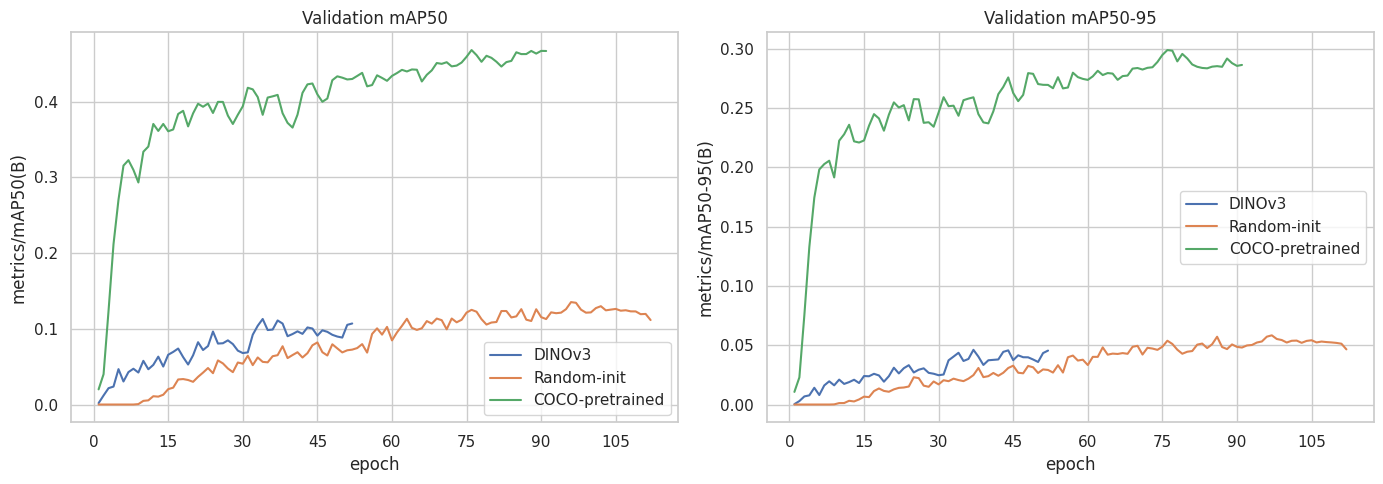

In [10]:
def load_history(project_dir, run_name):
    df = pd.read_csv(pathlib.Path(project_dir) / run_name / "results.csv")
    df.columns = df.columns.str.strip()
    return df

dinov3_hist = load_history(PROJECT_DIR, "dinov3_finetune")
rand_hist = load_history(BASELINE_PROJECT_DIR, "random_init_finetune")
coco_hist = load_history(BASELINE_PROJECT_DIR, "coco_pretrained_finetune")

display(dinov3_hist.tail().round(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in [("DINOv3", dinov3_hist), ("Random-init", rand_hist), ("COCO-pretrained", coco_hist)]:
    sns.lineplot(data=h, x="epoch", y="metrics/mAP50(B)", label=name, ax=axes[0])
    sns.lineplot(data=h, x="epoch", y="metrics/mAP50-95(B)", label=name, ax=axes[1])
axes[0].set_title("Validation mAP50"); axes[1].set_title("Validation mAP50-95")
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

## 8. Evaluate all three on the untouched 10% test split

In [11]:
def run_eval(weights_file, out_name):
    return evaluate(EvaluationConfig(
        model_name="yolo26n", weights_file=str(weights_file), data=str(DATA_YAML),
        output_dir=f"/kaggle/working/eval_{out_name}", split="test", image_size=IMAGE_SIZE,
        batch_size=GLOBAL_BATCH_SIZE, confidence=0.001, iou=0.7, max_detections=300,
        device=0, workers=WORKERS, half=True, plots=True, save_json=True,
    ))

eval_dinov3 = run_eval(DINOV3_BEST_DETECTOR, "dinov3")
eval_random = run_eval(RANDOM_INIT_BEST, "random_init")
eval_coco = run_eval(COCO_PRETRAINED_BEST, "coco_pretrained")

def headline(result):
    return json.loads(result.metrics_json.read_text())["headline_metrics"]

comparison = pd.DataFrame({
    "DINOv3 @ 20%": headline(eval_dinov3),
    "Random-init @ 20%": headline(eval_random),
    "COCO-pretrained @ 20%": headline(eval_coco),
}).round(5)
comparison

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.6 ms, read: 8.5±4.6 MB/s, size: 63.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/test/labels... 178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 253.0it/s 0.7s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.7s/it 16.5s
                   all        178        483      0.

,DINOv3 @ 20%,Random-init @ 20%,COCO-pretrained @ 20%
metrics/precision(B),0.20335,0.20100,0.45522
metrics/recall(B),0.17083,0.20770,0.48755
metrics/mAP50(B),0.10240,0.13562,0.42951
metrics/mAP50-95(B),0.03962,0.05695,0.28257
fitness,0.03962,0.05695,0.28257


## 8b. Per-class AP breakdown

Headline mAP hides which classes actually improved. Load each run's `per_class_csv` (task=box rows)
and compare AP50 per class.


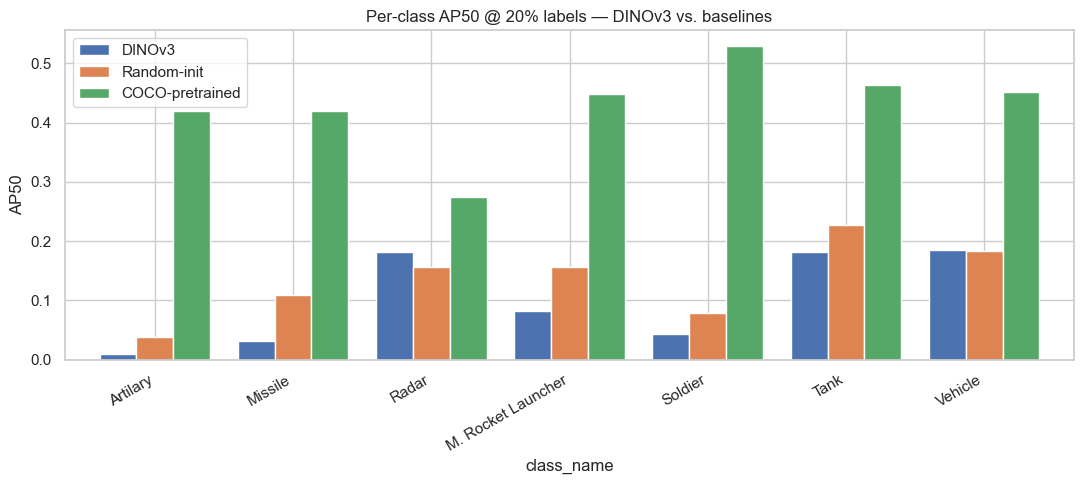

,DINOv3,Random-init,COCO-pretrained
class_name,,,
Artilary,0.0100,0.0376,0.4199
Missile,0.0323,0.1097,0.4194
Radar,0.1817,0.1560,0.2739
M. Rocket Launcher,0.0822,0.1566,0.4484
Soldier,0.0437,0.0784,0.5294
Tank,0.1814,0.2273,0.4633
Vehicle,0.1855,0.1838,0.4522


In [12]:
def load_per_class(result, label):
    df = pd.read_csv(result.per_class_csv)
    df = df[df["task"] == "box"][["class_name", "ap50"]].rename(columns={"ap50": label})
    return df.set_index("class_name")

per_class = load_per_class(eval_dinov3, "DINOv3").join(
    load_per_class(eval_random, "Random-init")).join(
    load_per_class(eval_coco, "COCO-pretrained"))
per_class = per_class.reindex(CLASS_NAMES)

ax = per_class.plot(kind="bar", figsize=(11, 5), width=0.8)
ax.set_ylabel("AP50"); ax.set_title("Per-class AP50 @ 20% labels — DINOv3 vs. baselines")
ax.legend(title=None); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()
per_class.round(4)

## 8c. Confusion matrix — DINOv3-initialized detector on the test split

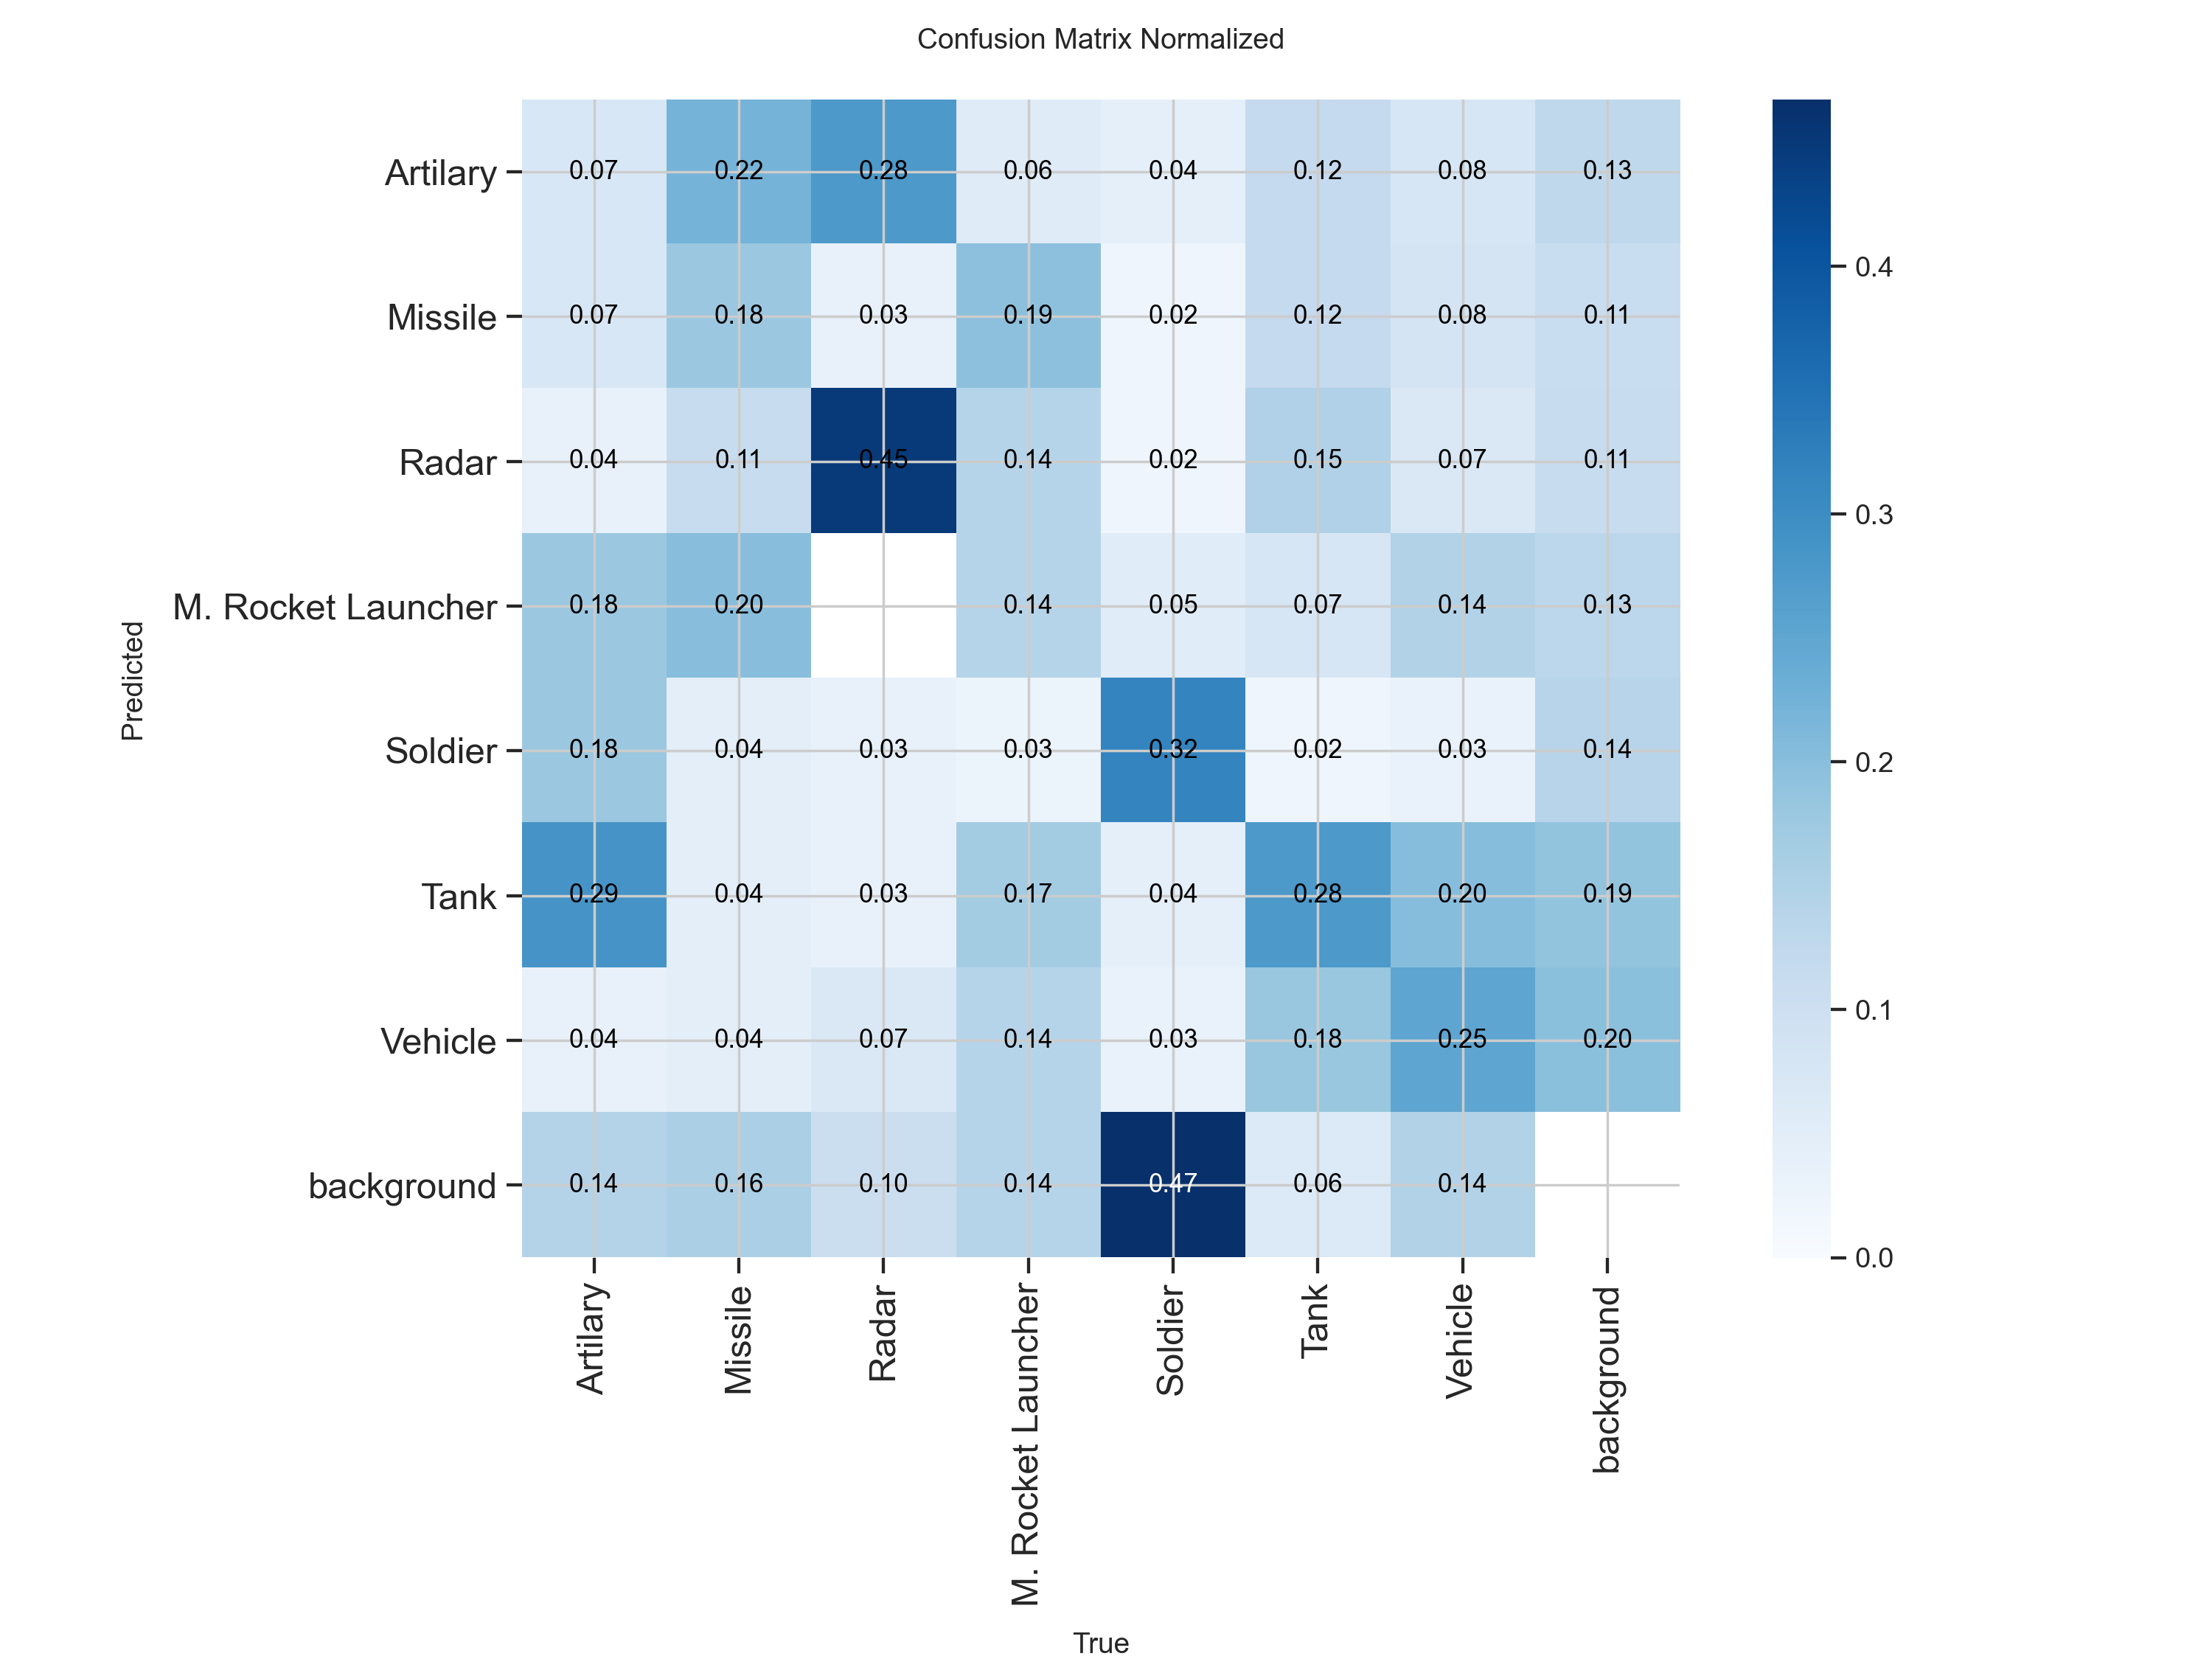

In [13]:
from PIL import Image

cm_path = eval_dinov3.output_dir / "confusion_matrix_normalized.png"
if not cm_path.exists():
    cm_path = eval_dinov3.output_dir / "confusion_matrix.png"
if cm_path.exists():
    display(Image.open(cm_path))
else:
    print("Confusion-matrix image not found at", eval_dinov3.output_dir, "- check plots=True took effect.")

## 8d. PR / F1 / Precision / Recall curves — DINOv3 vs. baselines, overlaid

Four separate plots (not one merged grid) — each shows all three runs on the same axes, built from
Ultralytics' raw curve data (`metrics.json`'s `"curves"` field) rather than pre-rendered per-model
images, so they can be directly overlaid and compared.


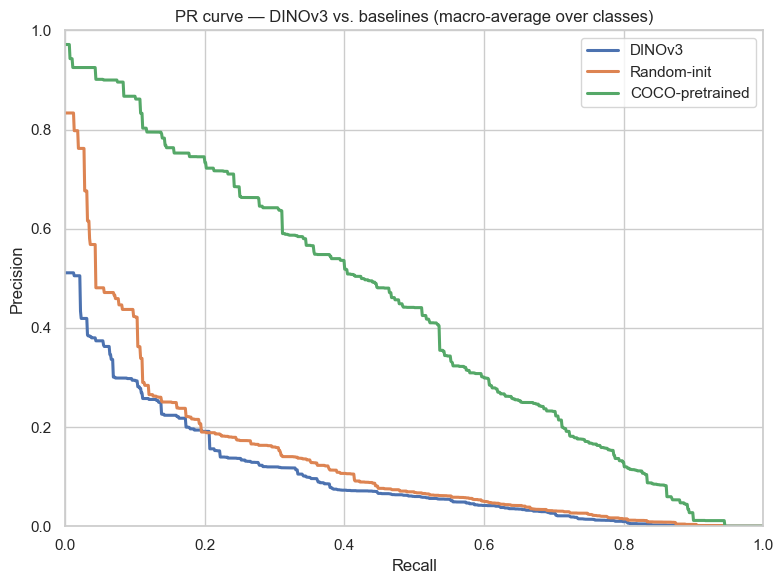

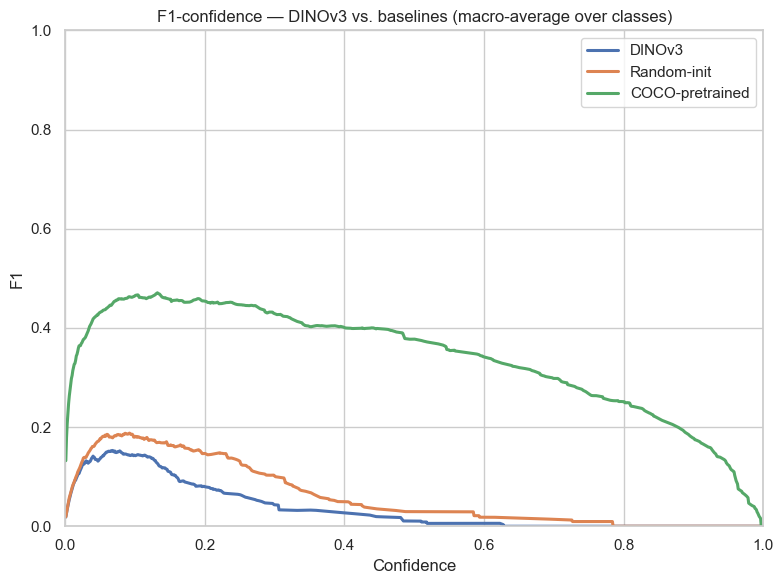

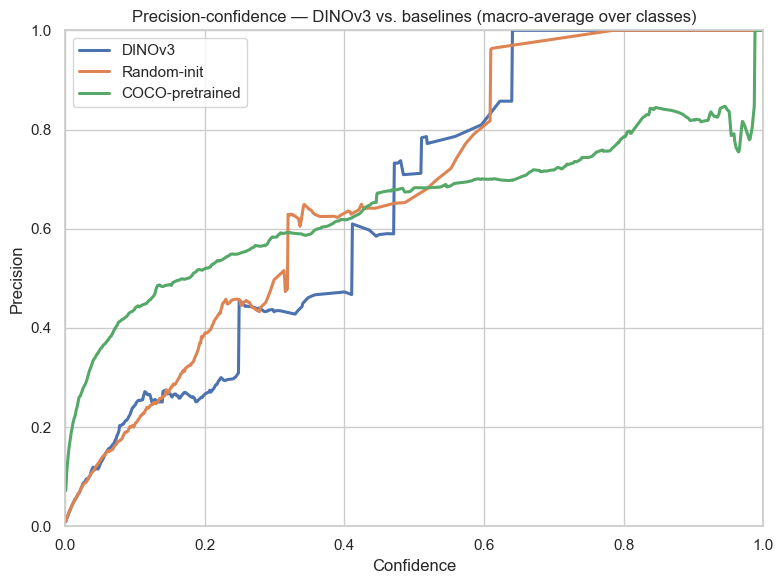

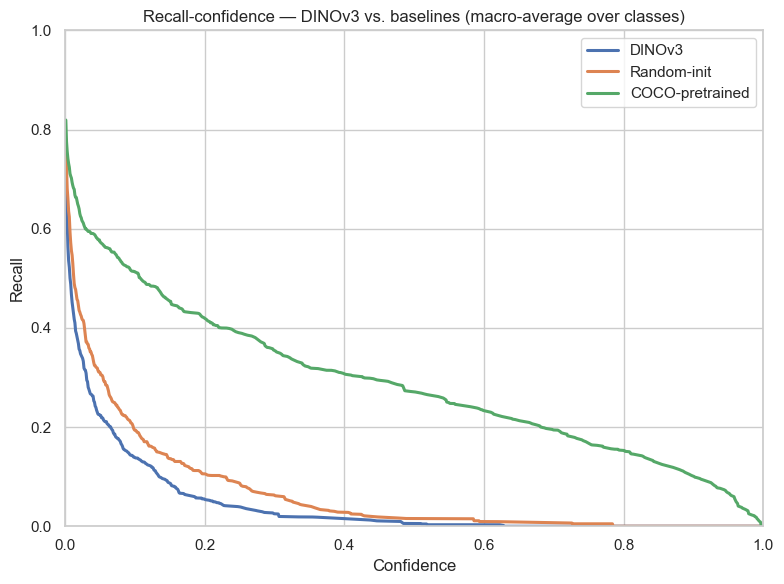

In [14]:
with open(DATA_YAML) as f:
    _data_yaml = yaml.safe_load(f)
TEST_IMG_DIR = pathlib.Path(_data_yaml["test"])
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
test_images = sorted(p for p in TEST_IMG_DIR.glob("*") if p.suffix.lower() in IMAGE_SUFFIXES)

def load_curves(eval_result):
    payload = json.loads((eval_result.output_dir / "metrics.json").read_text())
    return payload["curves"]

CURVE_NAMES = ["PR curve", "F1-confidence", "Precision-confidence", "Recall-confidence"]
RUNS = [("DINOv3", eval_dinov3), ("Random-init", eval_random), ("COCO-pretrained", eval_coco)]
curves_by_run = {label: load_curves(result) for label, result in RUNS}

for idx, curve_name in enumerate(CURVE_NAMES):
    fig, ax = plt.subplots(figsize=(8, 6))
    for label, _ in RUNS:
        x, y, xlabel, ylabel = curves_by_run[label][idx]
        x, y = np.array(x), np.array(y)
        y_mean = y.mean(axis=0) if y.ndim > 1 else y
        ax.plot(x, y_mean, linewidth=2.2, label=label)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f"{curve_name} — DINOv3 vs. baselines (macro-average over classes)")
    ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout(); plt.show()

## 8e. ROC curves and AUC (per-class + macro-average)

Object detection is normally scored with precision-recall (mAP), not ROC/AUC — ROC is a binary-classifier
tool. To produce it anyway: each predicted box counts as a positive detection event, matched against
ground truth at IoU >= 0.5 (true positive) or not (false positive); confidence score is the ranking
threshold. This is computed independently per class, then macro-averaged, for all three runs.


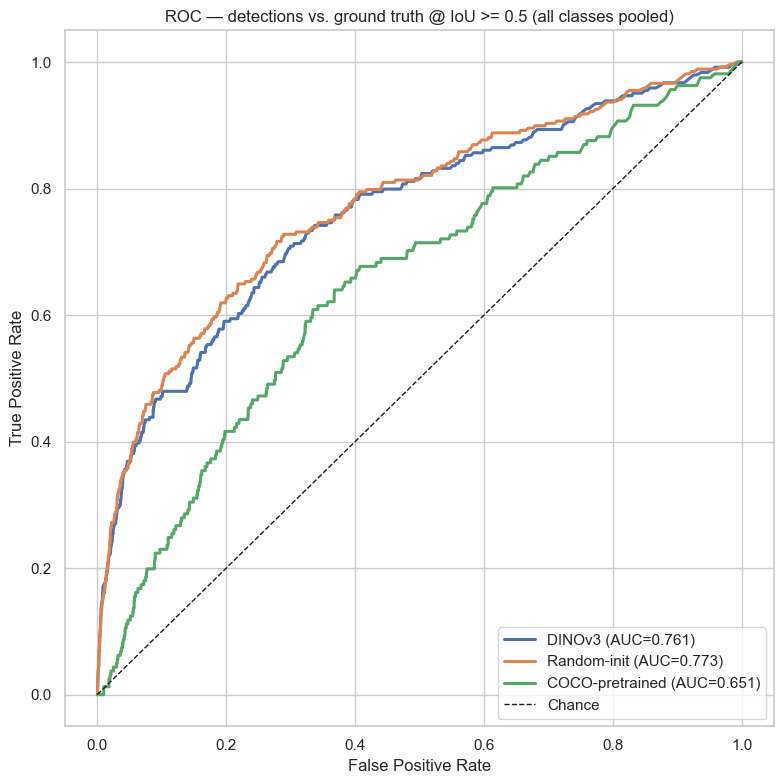

DINOv3             0.760968
Random-init        0.773187
COCO-pretrained    0.650979
Name: AUC, dtype: float64

In [15]:
from sklearn.metrics import roc_curve, auc

def load_gt_boxes(label_path, img_w, img_h):
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid = int(float(parts[0]))
            cx, cy, w, h = map(float, parts[1:5])
            x1, y1 = (cx - w / 2) * img_w, (cy - h / 2) * img_h
            x2, y2 = (cx + w / 2) * img_w, (cy + h / 2) * img_h
            boxes.append({"class_id": cid, "bbox": [x1, y1, x2, y2], "matched": False})
    return boxes

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    union = (ax2 - ax1) * (ay2 - ay1) + (bx2 - bx1) * (by2 - by1) - inter
    return inter / union if union > 0 else 0.0

def collect_scores_labels(eval_result, class_id, iou_thresh=0.5):
    preds = json.loads((eval_result.output_dir / "predictions.json").read_text())
    preds_by_image = {}
    for p in preds:
        if int(p["category_id"]) != class_id:
            continue
        preds_by_image.setdefault(str(p["image_id"]), []).append(p)

    y_scores, y_true = [], []
    for img_path in test_images:
        stem = img_path.stem
        lbl_path = TEST_IMG_DIR.parent / "labels" / f"{stem}.txt"
        with Image.open(img_path) as im:
            iw, ih = im.size
        gt_boxes = [b for b in load_gt_boxes(lbl_path, iw, ih) if b["class_id"] == class_id]

        image_preds = preds_by_image.get(stem, []) + preds_by_image.get(str(int(stem)) if stem.isdigit() else "__none__", [])
        image_preds = sorted(image_preds, key=lambda p: -p["score"])
        for p in image_preds:
            x, y, w, h = p["bbox"]
            box = [x, y, x + w, y + h]
            best_iou, best_gt = 0.0, None
            for gt in gt_boxes:
                if gt["matched"]:
                    continue
                iou = iou_xyxy(box, gt["bbox"])
                if iou > best_iou:
                    best_iou, best_gt = iou, gt
            is_tp = best_iou >= iou_thresh
            if is_tp:
                best_gt["matched"] = True
            y_scores.append(p["score"])
            y_true.append(1 if is_tp else 0)
    return np.array(y_scores), np.array(y_true)

fig, ax = plt.subplots(figsize=(8, 8))
macro_auc = {}
for label, result in RUNS:
    all_scores, all_true = [], []
    for cid in range(len(CLASS_NAMES)):
        s, t = collect_scores_labels(result, cid)
        if len(s) and t.sum() > 0:
            all_scores.append(s); all_true.append(t)
    if not all_scores:
        print(f"{label}: no true positives found at IoU>=0.5, skipping ROC"); continue
    y_scores, y_true = np.concatenate(all_scores), np.concatenate(all_true)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    macro_auc[label] = roc_auc
    ax.plot(fpr, tpr, linewidth=2.2, label=f"{label} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — detections vs. ground truth @ IoU >= 0.5 (all classes pooled)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

pd.Series(macro_auc, name="AUC")

## 9. Qualitative predictions on test images

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


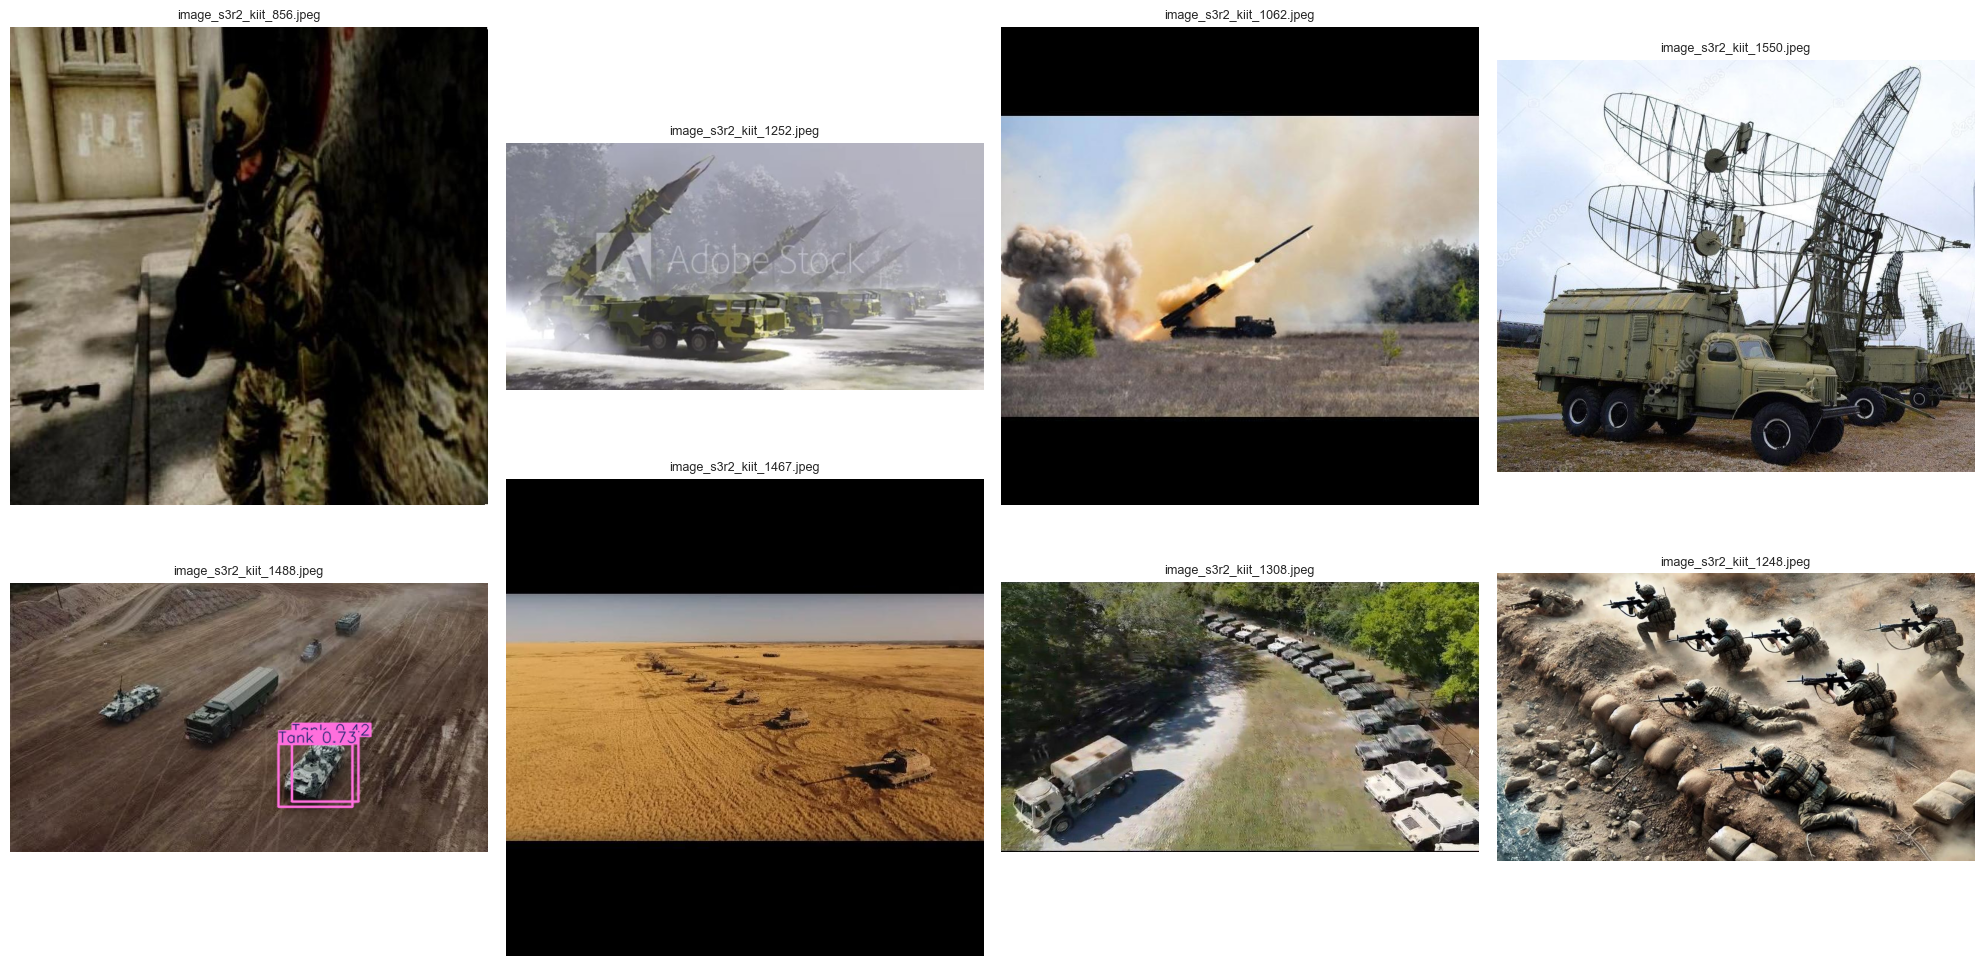

In [16]:
sample_paths = random.Random(SEED).sample(test_images, min(8, len(test_images)))

prediction_model = YOLO(str(DINOV3_BEST_DETECTOR))
results = prediction_model.predict(source=[str(p) for p in sample_paths], imgsz=IMAGE_SIZE,
                                    conf=0.25, iou=0.7, device=0, half=True, verbose=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax in axes.flat:
    ax.axis("off")
for ax, r in zip(axes.flat, results):
    ax.imshow(r.plot()[..., ::-1])
    ax.set_title(Path(r.path).name, fontsize=9)
plt.tight_layout(); plt.show()